Saving Rental indicators for cities in Makkah region.csv to Rental indicators for cities in Makkah region (10).csv

Data size:
(2066, 7)

Column names:
Index(['السنة ', 'الربع', 'المنطقة ', 'المدينة ', 'نوع العقار ',
       'مجموع الصفقات', 'المتوسط'],
      dtype='object')

Column 'المنطقة' removed because it is constant and not informative.


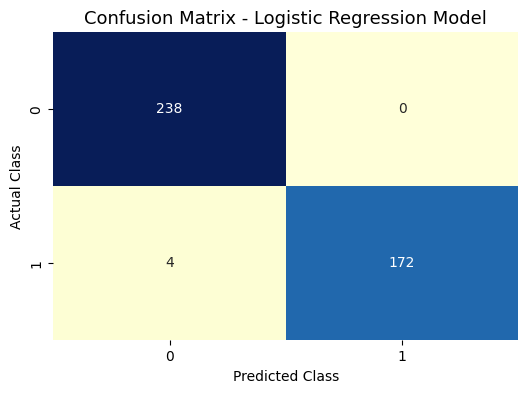


Number of wrong predictions: 4

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       238
           1       1.00      0.98      0.99       176

    accuracy                           0.99       414
   macro avg       0.99      0.99      0.99       414
weighted avg       0.99      0.99      0.99       414


Model Accuracy: 99.03%

Top 5 cities most affected by rent (by predicted probability):



,Rank,City,Impact Probability (%)
0,1,جدة,59.37%
1,2,ثول,53.43%
2,3,مكة المكرمة,52.64%
3,4,الطائف,52.19%
4,5,الجموم - بحرة,48.34%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from google.colab import files


uploaded = files.upload()
df = pd.read_csv("Rental indicators for cities in Makkah region.csv")


print("\nData size:")
print(df.shape)
print("\nColumn names:")
print(df.columns)


df.columns = df.columns.str.strip()


if 'المنطقة' in df.columns:
    df = df.drop(columns=['المنطقة'])
    print("\nColumn 'المنطقة' removed because it is constant and not informative.")


threshold = df['المتوسط'].mean()
df['مستوى_التأثر'] = (df['المتوسط'] > threshold).astype(int)


le_city = LabelEncoder()
le_type = LabelEncoder()
df['رمز_المدينة'] = le_city.fit_transform(df['المدينة'])
df['رمز_العقار'] = le_type.fit_transform(df['نوع العقار'])


X = df[['رمز_المدينة', 'رمز_العقار', 'المتوسط', 'مجموع الصفقات']].fillna(0)
y = df['مستوى_التأثر']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Confusion Matrix - Logistic Regression Model', fontsize=13)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()


wrong = cm[0][1] + cm[1][0]
print(f"\nNumber of wrong predictions: {wrong}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
acc = accuracy_score(y_test, y_pred) * 100
print(f"\nModel Accuracy: {acc:.2f}%")


X_scaled_all = scaler.transform(X)
df['احتمالية_التأثر'] = model.predict_proba(X_scaled_all)[:, 1] * 100


top_n = 5
top_cities = (
    df.groupby('المدينة')['احتمالية_التأثر']
    .mean()
    .sort_values(ascending=False)
    .head(top_n)
)


table = pd.DataFrame({
    "Rank": range(1, len(top_cities) + 1),
    "City": top_cities.index,
    "Impact Probability (%)": top_cities.values.round(2)
})
table["Impact Probability (%)"] = table["Impact Probability (%)"].astype(str) + "%"

# Light styling for display in Colab/Jupyter
styled_table = table.style.set_properties(**{
    'background-color': '#111',
    'color': 'white',
    'border-color': 'gray',
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th',
    'props': [
        ('background-color', '#222'),
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('text-align', 'center')
    ]
}])

# Display the final table
print(f"\nTop {top_n} cities most affected by rent (by predicted probability):\n")
display(styled_table)